In [1]:
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import *

c:\Users\neera\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
x_test = joblib.load("d:\\Codes\\Patient_Readmission_Prediction\\models\\x_test_processed.pkl")
y_test = joblib.load("d:\\Codes\\Patient_Readmission_Prediction\\models\\y_test.pkl")
preprocessor = joblib.load("d:\\Codes\\Patient_Readmission_Prediction\\models\\preprocessor.pkl")

feature_names = preprocessor.get_feature_names_out()
x_test_df = pd.DataFrame(x_test, columns=feature_names)
x_test_df.head()

,num__time_in_hospital,num__num_lab_procedures,num__num_procedures,num__num_medications,num__number_outpatient,num__number_emergency,num__number_inpatient,num__number_diagnoses,num__age_numeric,num__total_prior_visits,...,cat__diabetesMed_Yes,cat__diag1_category_Circulatory,cat__diag1_category_Diabetes,cat__diag1_category_Digestive,cat__diag1_category_Genitourinary,cat__diag1_category_Injury,cat__diag1_category_Musculoskeletal,cat__diag1_category_Neoplasms,cat__diag1_category_Other,cat__diag1_category_Respiratory
0,-0.105790,-1.831527,0.346859,0.500520,-0.273432,-0.223436,-0.467871,0.338640,0.574441,-0.503634,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.563973,-0.119167,1.498471,2.796147,-0.273432,-0.223436,-0.467871,-1.682743,0.574441,-0.503634,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.563973,-1.881891,-0.804754,0.862987,-0.273432,-0.223436,-0.467871,0.843986,1.200497,-0.503634,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.105790,-0.018440,-0.804754,0.138052,-0.273432,1.391884,-0.467871,0.843986,-1.303727,0.034872,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.105790,-0.824256,-0.228948,-1.553463,-0.273432,-0.223436,0.533317,-1.177397,0.574441,0.034872,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [4]:
lr = joblib.load("d:\\Codes\\Patient_Readmission_Prediction\\models\\trained\\logistic_regression_model.pkl")
rf = joblib.load("d:\\Codes\\Patient_Readmission_Prediction\\models\\trained\\random_forest_model.pkl")
dt = joblib.load("d:\\Codes\\Patient_Readmission_Prediction\\models\\trained\\decision_tree_model.pkl")

In [5]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Decision Tree": dt
}

results = []
for name, model in models.items():
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.708054   0.081337  0.531783  0.141094
1        Random Forest  0.857592   0.108989  0.300775  0.160000
2        Decision Tree  0.919114   0.139437  0.153488  0.146125


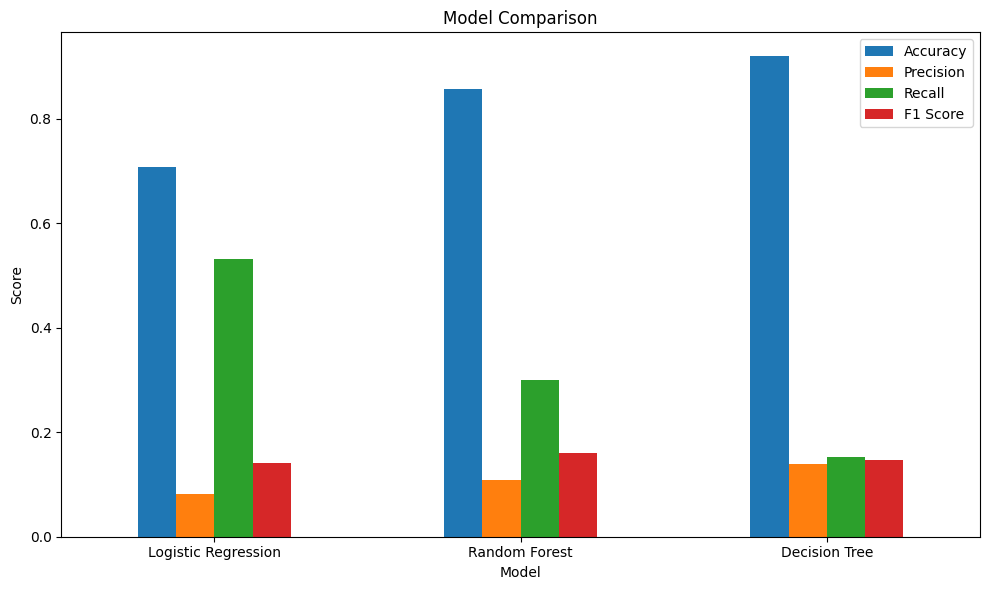

In [8]:
results_df.set_index("Model").plot(kind='bar', figsize=(10, 6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
y_pred_rf = rf.predict(x_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.88      0.92     13659
           1       0.11      0.30      0.16       645

    accuracy                           0.86     14304
   macro avg       0.54      0.59      0.54     14304
weighted avg       0.93      0.86      0.89     14304



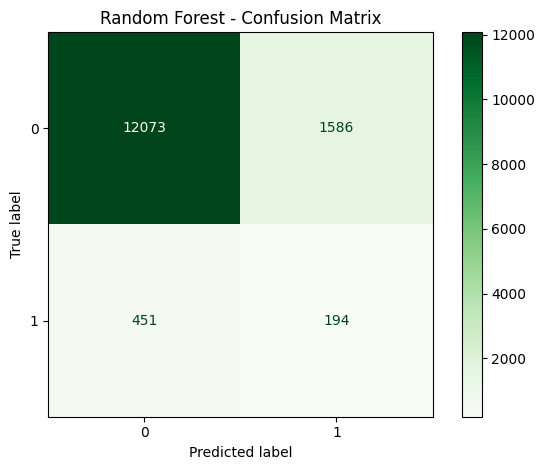

In [10]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = "Greens")
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

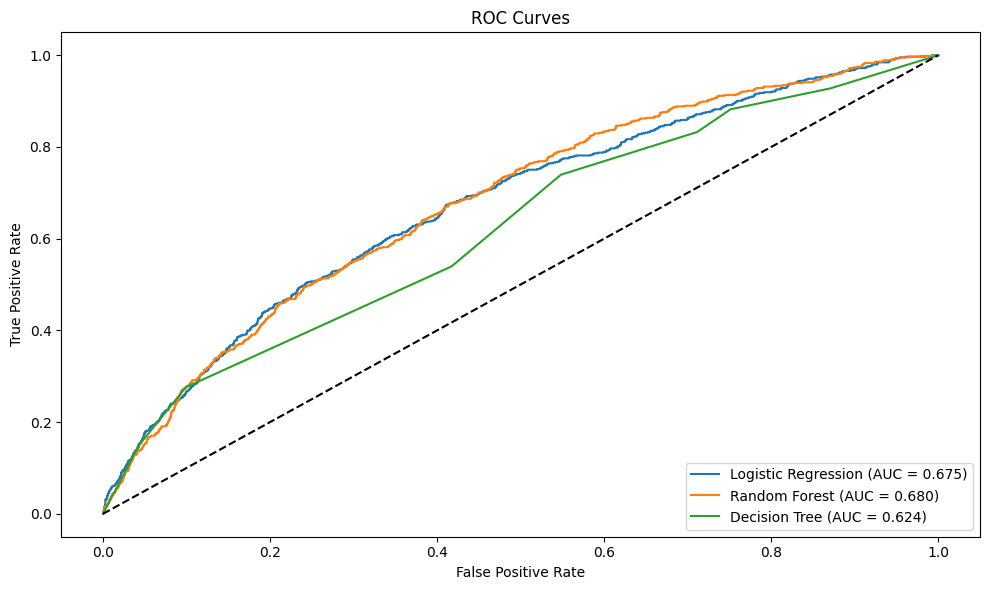

In [11]:
plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.legend(loc='lower right')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

In [17]:
print(type(shap_values))

try:
    print(shap_values.shape)
except:
    pass

try:
    print(shap_values.values.shape)
except:
    pass

<class 'shap._explanation.Explanation'>
(50, 2244, 2)
(50, 2244, 2)


SHAP Values Shape: (50, 2244, 2)


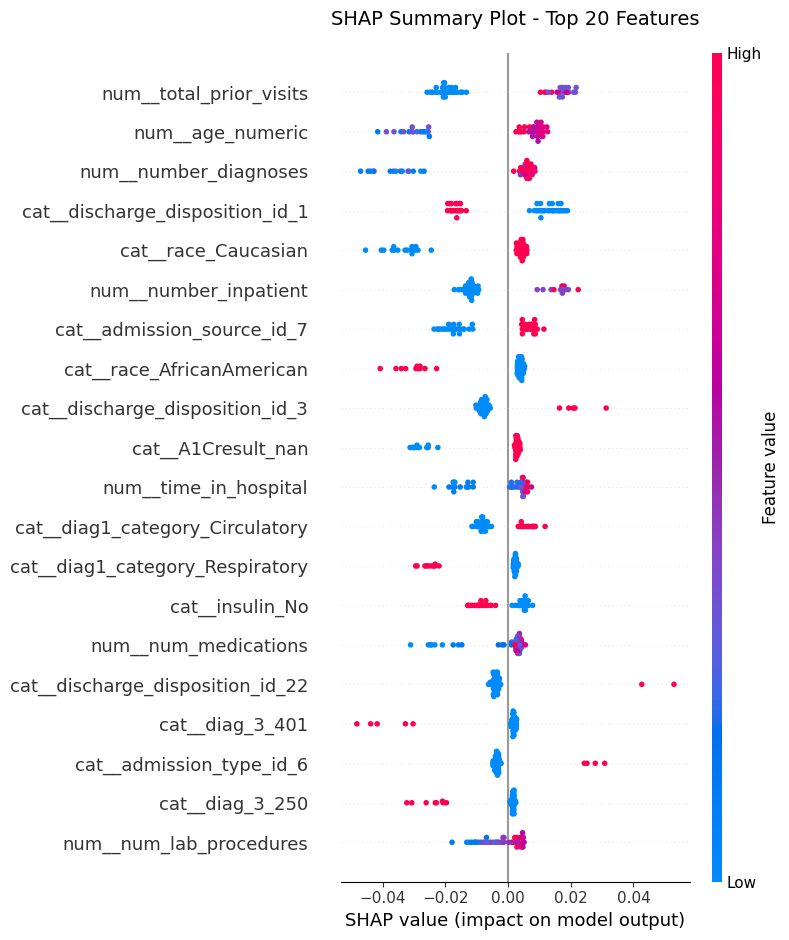

In [24]:
x_sample = x_test_df.iloc[:50]

explainer = shap.TreeExplainer(rf)

shap_values = explainer(x_sample)

print("SHAP Values Shape:", shap_values.values.shape)

plt.figure(figsize=(14,10))

shap.summary_plot(
    shap_values[:, :, 1],   # Class 1 = Readmission
    x_sample,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot - Top 20 Features",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

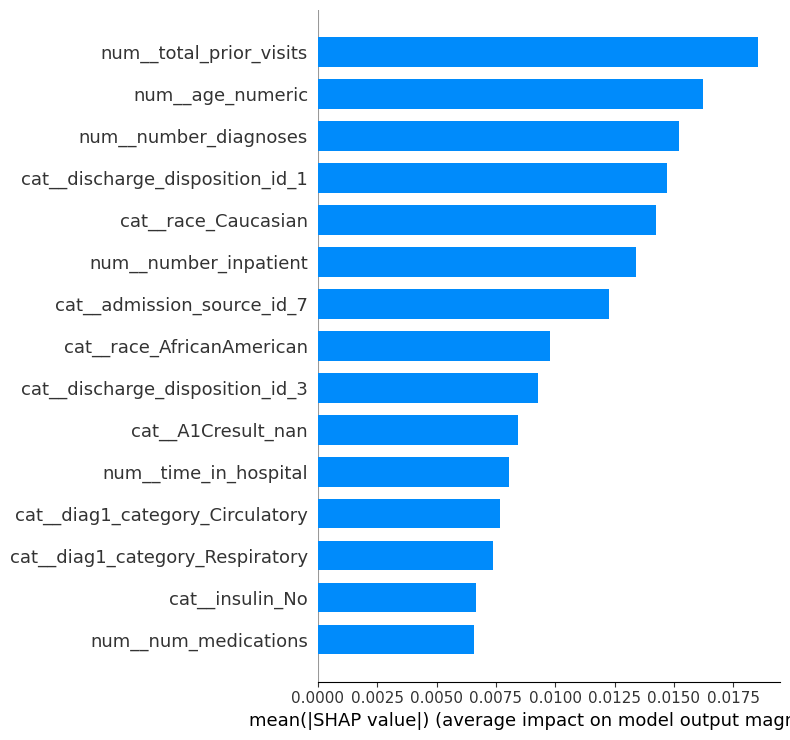

<Figure size 640x480 with 0 Axes>

In [23]:
shap.summary_plot(
    shap_values[:, :, 1],
    x_sample,
    plot_type="bar",
    max_display=15,
)

plt.subplots_adjust(bottom=0.28, left=0.22)